# 01a – Data Quality: NYC Citi Bike

**Worked on by:** Andreas Schellekens (file inventory, harmonised schema, Parquet conversion, conversion checks)

> **GenAI disclosure:** the first version of this notebook was drafted with the help of Claude Code (AI assistant). All findings and decisions were reviewed by the team; we must be able to explain every cell ourselves.

## 1. Setup

The Citi Bike data is about 330 million trips in 400 CSV files (about 62 GB). That does not fit in memory, so we do not load it with pandas. Instead we use **DuckDB**, a database that runs inside Python: it runs SQL directly on CSV and Parquet files, streams through them in parallel and only keeps the result in memory. Results of a query come back as a small pandas DataFrame for tables and plots (matplotlib).

The data itself is not in git. Step 00 (`00_download_citibike.py`) downloads and assembles it into `Data/<year>-citibike-tripdata/<month>/`. All paths in this notebook are relative to the `NYCCitiBikeSystemData/` folder.

In [1]:
import os
import time
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 200)

# One quiet plot style for the whole notebook: light grid, no top/right frame, grey axis text
INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white", "axes.edgecolor": "#c3c2b7",
    "axes.grid": True, "grid.color": "#e1e0d9", "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.labelcolor": INK_SECONDARY, "xtick.color": INK_MUTED, "ytick.color": INK_MUTED,
    "text.color": INK_PRIMARY, "axes.titlesize": 12, "axes.titleweight": "bold",
})
DIVERGING = LinearSegmentedColormap.from_list("decline_growth", ["#c43c3b", "#f0efec", "#1c5cab"])  # red - grey - blue

DATA_DIR = Path("Data")
PARQUET_DIR = DATA_DIR / "parquet" / "trips"  # output of this notebook, git-ignored like all of Data/

con = duckdb.connect()  # in-memory database: the tables stay in the files, only results are kept
con.execute("SET enable_progress_bar = false")  # the progress bar only clutters the notebook output
print("DuckDB", duckdb.__version__)

DuckDB 1.5.6


## 2. Which files we read

Step 00 places the trips of every month as one or more CSV parts (at most 1,000,000 trips each) directly in the month folder. For 2013 and 2018 Citi Bike also ships an **unsplit copy** of every month; step 00 puts that copy in a subfolder `Origineel/`. Reading both would count every trip of those months twice.

We therefore read only the CSVs **directly inside** a month folder (`Data/*/*/*.csv`); the `Origineel/` files are one level deeper and are not matched by this pattern. Section 4.2 proves that the split parts contain exactly the same number of trips as the unsplit copies, so nothing is lost by skipping them.

For every file we also read the first line (the header) to know which of the three CSV formats it uses:

| Format | Period | Header |
|---|---|---|
| `old` | 2013-06 to 2016-09, 2017-04 to 2019-12 | `tripduration,starttime,...` (lowercase) |
| `old_title_case` | 2016-10 to 2017-03 | `Trip Duration,Start Time,...` (same 15 columns in Title Case) |
| `new` | 2020-01 onwards | `ride_id,rideable_type,started_at,...` (13 columns, new system) |

In [2]:
FORMAT_BY_HEADER = {  # start of the header line -> format name
    "tripduration,": "old",
    "Trip Duration,": "old_title_case",
    "ride_id,": "new",
}
MONTH_NAMES = ["January", "February", "March", "April", "May", "June", "July",
               "August", "September", "October", "November", "December"]


def csv_format(path):
    with open(path, encoding="utf-8") as f:
        header = f.readline()
    for prefix, name in FORMAT_BY_HEADER.items():
        if header.startswith(prefix):
            return name
    raise ValueError(f"unknown header in {path}: {header[:80]}")


rows = []
for path in sorted(DATA_DIR.glob("*-citibike-tripdata/*/*.csv")):
    year, month = int(path.name[:4]), int(path.name[4:6])
    rows.append({
        "file": path.name,
        "path": path.as_posix(),
        "month": f"{year}-{month:02d}",
        "folder_matches": path.parent.name == f"{month}_{MONTH_NAMES[month - 1]}"
                          and path.parent.parent.name == f"{year}-citibike-tripdata",
        "format": csv_format(path),
        "size_mb": path.stat().st_size / 1e6,
    })
files = pd.DataFrame(rows)
skipped = sorted(DATA_DIR.glob("*-citibike-tripdata/*/Origineel/*.csv"))

print(f"{len(files)} CSV files read ({files.size_mb.sum() / 1e3:.1f} GB), "
      f"{files.month.nunique()} months, from {files.month.min()} to {files.month.max()}")
print(f"{len(skipped)} unsplit copies in Origineel/ skipped "
      f"({sum(p.stat().st_size for p in skipped) / 1e9:.1f} GB)")

400 CSV files read (60.9 GB), 159 months, from 2013-06 to 2026-08
19 unsplit copies in Origineel/ skipped (4.4 GB)


The inventory finds 400 CSV files (60.9 GB) for 159 months, June 2013 to August 2026, and skips the 19 unsplit copies in `Origineel/` (4.4 GB).

Before converting anything we check that the inventory is consistent: every file sits in the folder of its own month, no file name occurs twice, all files of a month use the same format, and there is no month missing between the first and the last month.

In [3]:
all_months = pd.period_range(files.month.min(), files.month.max(), freq="M").strftime("%Y-%m")
formats_per_month = files.groupby("month").format.nunique()

assert files.folder_matches.all(), "a file is in the wrong month folder"
assert files.file.is_unique, "a file name occurs twice"
assert formats_per_month.max() == 1, "a month mixes CSV formats"
missing_months = sorted(set(all_months) - set(files.month))
print("Missing months:", missing_months or "none")

summary = (files.assign(year=files.month.str[:4])
           .groupby("year")
           .agg(files=("file", "size"), months=("month", "nunique"), size_gb=("size_mb", "sum"),
                formats=("format", lambda s: ", ".join(sorted(s.unique())))))
summary["size_gb"] = (summary.size_gb / 1e3).round(2)
summary

Missing months: none


,files,months,size_gb,formats
year,,,,
2013,10,7,0.92,old
2014,12,12,1.33,old
2015,16,12,1.62,old
2016,20,12,2.31,"old, old_title_case"
2017,20,12,2.78,"old, old_title_case"
2018,21,12,3.19,old
2019,26,12,3.73,old
2020,27,12,3.61,new
2021,36,12,5.22,new


All checks pass: no month is missing, every file is in the folder of its own month and every month uses a single format. The data grows from 0.9 GB for the 7 months of 2013 to 8.9 GB for 2025. 2016 and 2017 contain both old formats (Title Case from October 2016 to March 2017); from 2020 on everything is in the new format.

## 3. One harmonised schema, stored as Parquet

### 3.1 The column mapping

The three formats describe the same thing (one row = one trip) with different column names and value formats. We map them to one schema. Columns that exist in only one format are kept, and are empty (NULL) for the other format; we do not invent values.

| Harmonised column | `old` / `old_title_case` | `new` | Notes |
|---|---|---|---|
| `ride_id` | - | `ride_id` | unique trip id, only in the new system |
| `started_at`, `ended_at` | `starttime`, `stoptime` | `started_at`, `ended_at` | local New York time (no time zone in the data) |
| `duration_s` | computed | computed | `ended_at - started_at` in seconds, the same definition for every format |
| `tripduration_s` | `tripduration` | - | duration as reported by the old system, kept to compare with `duration_s` |
| `start_station_id`, `end_station_id` | `start station id` | `start_station_id` | text; old ids are whole numbers (`3359`), new ids look like `6890.01` |
| `start_station_name`, `end_station_name` | `start station name` | `start_station_name` | |
| `start_lat`, `start_lng`, `end_lat`, `end_lng` | `start station latitude`, ... | `start_lat`, ... | decimal degrees |
| `user_type` | `usertype`: Subscriber -> `member`, Customer -> `casual` | `member_casual` | annual subscriber vs. day pass / single ride |
| `rideable_type` | - | `rideable_type` | classic or electric bike, only recorded since 2020 |
| `bike_id` | `bikeid` | - | |
| `birth_year`, `gender` | `birth year`, `gender` | - | gender: 0 = unknown, 1 = male, 2 = female |
| `source_format`, `source_month`, `source_file` | added | added | where the row came from, for checks and tracing |

### 3.2 Parsing choices

- **The CSV dialect is fixed** (comma separator, `"` as quote character). DuckDB normally guesses it from a sample of each file; our first run failed on April 2017, because the sample of that file had no quoted value, so DuckDB assumed there were no quotes, and then met `"Industry City, Building 1 Basement"` (a station name with a comma) further down. DuckDB's strict mode stops on such a row instead of silently shifting the columns, which is what we want.
- **Everything is read as text first** (`all_varchar=true`) and then converted with `try_cast`. A value that cannot be converted becomes NULL instead of stopping the whole conversion, and section 4.3 counts how often that happens. Letting DuckDB guess the types per file would give different types in different years.
- **Timestamps** come in four shapes: `2013-10-01 00:01:08` (ISO), `2019-09-25 17:33:01.4710` (ISO with 4 decimals, 2018-2019), `9/1/2014 00:00:25` (US month/day/year, 2014-09 to 2016-09) and `3/1/2015 0:00` (US without seconds, January to June 2015). We try the ISO cast first and then the two US patterns.
- **Station ids** of the old system are sometimes written as `3359.0` (2018-2019), so they are converted to a whole number before being stored as text.
- **Station ids** of the new system look like `6890.01`: a station number, a dot and **two** digits. They are text, not numbers. But in every month since 2020 a small share of the rows (even within one file) writes an id ending in zero with one digit: `5024.1` instead of `5024.10`, as if the value had passed through a number format. A first conversion without a fix showed 114 such one-digit ids; 103 of them also occur in the two-digit form, and for 99 of those the most common station name is identical (the other 4 differ only in spelling, e.g. `St. Nicholas` vs `St Nicholas`). They are the same stations, so a one-digit id gets its zero back (`5024.1` -> `5024.10`). Without this fix one station would count as two in every station analysis.
- **Birth year** is written as `1982`, `1992.0`, `\N` or left empty; the last two become NULL.
- The column names of the CSV header are replaced by our own names (`names=`), which makes `old` and `old_title_case` identical: their 15 columns are in the same order.

In [4]:
OLD_COLUMNS = ["tripduration", "starttime", "stoptime", "start_station_id", "start_station_name", "start_lat",
               "start_lng", "end_station_id", "end_station_name", "end_lat", "end_lng", "bikeid", "usertype",
               "birth_year", "gender"]
NEW_COLUMNS = ["ride_id", "rideable_type", "started_at", "ended_at", "start_station_name", "start_station_id",
               "end_station_name", "end_station_id", "start_lat", "start_lng", "end_lat", "end_lng", "member_casual"]


# Fixed CSV dialect: DuckDB would otherwise guess it from a sample of each file, and a file whose sample has no
# quoted value would be read without quotes (a name like "Industry City, Building 1" would then split in two)
CSV_OPTIONS = "header=true, all_varchar=true, delim=',', quote='\"', escape='\"', filename=true"


def timestamp(column):
    return (f"coalesce(try_cast({column} AS TIMESTAMP), "
            f"try_strptime({column}, ['%m/%d/%Y %H:%M:%S', '%m/%d/%Y %H:%M']))")


def old_station_id(column):
    return f"CAST(try_cast(try_cast({column} AS DOUBLE) AS INTEGER) AS VARCHAR)"


def new_station_id(column):
    return (f"CASE WHEN regexp_matches({column}, '^[0-9]+\\.[0-9]$') THEN {column} || '0' "
            f"ELSE nullif({column}, '') END")


def select_trips(paths, csv_format, month):
    """SQL that reads the CSVs of one month and returns the trips in the harmonised schema."""
    year, month_number = map(int, month.split("-"))
    if csv_format == "new":
        trips = f"""
            SELECT ride_id, {timestamp('started_at')} AS started_at, {timestamp('ended_at')} AS ended_at,
                   NULL::INTEGER AS tripduration_s,
                   {new_station_id('start_station_id')} AS start_station_id, nullif(start_station_name, '') AS start_station_name,
                   try_cast(start_lat AS DOUBLE) AS start_lat, try_cast(start_lng AS DOUBLE) AS start_lng,
                   {new_station_id('end_station_id')} AS end_station_id, nullif(end_station_name, '') AS end_station_name,
                   try_cast(end_lat AS DOUBLE) AS end_lat, try_cast(end_lng AS DOUBLE) AS end_lng,
                   nullif(member_casual, '') AS user_type, nullif(rideable_type, '') AS rideable_type,
                   NULL::INTEGER AS bike_id, NULL::SMALLINT AS birth_year, NULL::TINYINT AS gender, filename
            FROM read_csv({paths}, {CSV_OPTIONS}, names={NEW_COLUMNS})"""
    else:
        trips = f"""
            SELECT NULL::VARCHAR AS ride_id, {timestamp('starttime')} AS started_at, {timestamp('stoptime')} AS ended_at,
                   try_cast(tripduration AS INTEGER) AS tripduration_s,
                   {old_station_id('start_station_id')} AS start_station_id, nullif(start_station_name, '') AS start_station_name,
                   try_cast(start_lat AS DOUBLE) AS start_lat, try_cast(start_lng AS DOUBLE) AS start_lng,
                   {old_station_id('end_station_id')} AS end_station_id, nullif(end_station_name, '') AS end_station_name,
                   try_cast(end_lat AS DOUBLE) AS end_lat, try_cast(end_lng AS DOUBLE) AS end_lng,
                   CASE usertype WHEN 'Subscriber' THEN 'member' WHEN 'Customer' THEN 'casual' END AS user_type,
                   NULL::VARCHAR AS rideable_type, try_cast(bikeid AS INTEGER) AS bike_id,
                   try_cast(try_cast(birth_year AS DOUBLE) AS SMALLINT) AS birth_year,
                   try_cast(gender AS TINYINT) AS gender, filename
            FROM read_csv({paths}, {CSV_OPTIONS}, names={OLD_COLUMNS})"""
    return f"""
        SELECT ride_id, started_at, ended_at,
               date_diff('millisecond', started_at, ended_at) / 1000.0 AS duration_s, tripduration_s,
               start_station_id, start_station_name, start_lat, start_lng,
               end_station_id, end_station_name, end_lat, end_lng,
               user_type, rideable_type, bike_id, birth_year, gender,
               '{csv_format}' AS source_format, DATE '{year}-{month_number:02d}-01' AS source_month,
               parse_filename(filename) AS source_file
        FROM ({trips})"""

### 3.3 Conversion to Parquet

Parquet is a compressed, column-based file format. A query that needs two columns only reads those two columns, and the files are several times smaller than the CSVs. We write **one Parquet file per month** (`Data/parquet/trips/trips_YYYY-MM.parquet`):

- A month that is already converted is skipped, so re-running the notebook takes seconds, and a month added later by step 00 is converted on the next run. To rebuild everything, delete `Data/parquet/`.
- Each file is first written under a temporary name and only renamed when it is complete, so an interrupted run never leaves a half file that would later be skipped as "done".
- All later notebooks read the trips with `read_parquet('Data/parquet/trips/*.parquet')`.

The first run converts all 61 GB in about 4 minutes (221 s on our laptop); the Parquet files take about 10 GB, a sixth of the CSV size.

In [5]:
PARQUET_DIR.mkdir(parents=True, exist_ok=True)
start = time.time()
converted = 0
for month, month_files in files.groupby("month"):
    target = PARQUET_DIR / f"trips_{month}.parquet"
    if target.exists():
        continue
    temporary = target.with_suffix(".parquet.tmp")
    sql = select_trips(month_files.path.tolist(), month_files.format.iloc[0], month)
    con.execute(f"COPY ({sql}) TO '{temporary.as_posix()}' (FORMAT parquet, COMPRESSION zstd)")
    os.replace(temporary, target)
    converted += 1
    print(f"{month}: {len(month_files)} file(s) converted", flush=True)

parquet_files = sorted(PARQUET_DIR.glob("trips_*.parquet"))
print(f"\n{converted} month(s) converted in {time.time() - start:.0f} s; "
      f"{len(parquet_files)} Parquet files, {sum(p.stat().st_size for p in parquet_files) / 1e9:.1f} GB "
      f"(CSV: {files.size_mb.sum() / 1e3:.1f} GB)")


0 month(s) converted in 0 s; 159 Parquet files, 10.4 GB (CSV: 60.9 GB)


From here on the trips are one view called `trips` over all Parquet files. A view is only a stored query: it costs nothing until it is used, and it always reads the files as they are at that moment.

In [6]:
con.execute(f"CREATE OR REPLACE VIEW trips AS SELECT * FROM read_parquet('{PARQUET_DIR.as_posix()}/*.parquet')")
con.sql("DESCRIBE trips").df()[["column_name", "column_type"]]

,column_name,column_type
0,ride_id,VARCHAR
1,started_at,TIMESTAMP
2,ended_at,TIMESTAMP
3,duration_s,DOUBLE
4,tripduration_s,INTEGER
5,start_station_id,VARCHAR
6,start_station_name,VARCHAR
7,start_lat,DOUBLE
8,start_lng,DOUBLE
9,end_station_id,VARCHAR


### 3.4 Trips that are stored twice

Skipping `Origineel/` prevents whole months from being read twice, but a single trip can still occur in two files. To find such trips we need a key that identifies one trip:

- **New system:** `ride_id`, the unique id of every trip.
- **Old system:** there is no trip id, but one bike cannot start two trips in the same second, so `bike_id` + `started_at` identifies a trip.

The search first groups all trips on these keys and keeps only the keys that occur more than once (about a minute), and then fetches the rows of those few keys. Grouping all 323 million complete rows directly took more than 20 minutes.

Our rule: every trip is kept **once**, in the file of the month in which it **started** (that is where Citi Bike normally puts it). When both copies are in the same file, the copy with the earliest end time is kept, so the choice is the same on every run. The removed copies are written to `Data/parquet/removed_duplicates.parquet`, so they remain traceable and section 4.1 can still match every CSV row. Only the affected month files are rewritten, and on a re-run nothing is found any more and nothing changes.

In [7]:
REMOVED_PATH = DATA_DIR / "parquet" / "removed_duplicates.parquet"


def find_duplicated_keys():
    """Table duplicated_keys: every ride_id, and every bike_id + started_at (old system), that occurs more than once."""
    con.execute("""
        CREATE OR REPLACE TABLE duplicated_keys AS
        SELECT ride_id, NULL::INTEGER AS bike_id, NULL::TIMESTAMP AS started_at FROM trips
        WHERE ride_id IS NOT NULL GROUP BY ride_id HAVING count(*) > 1
        UNION ALL
        SELECT NULL, bike_id, started_at FROM trips
        WHERE ride_id IS NULL AND bike_id IS NOT NULL GROUP BY bike_id, started_at HAVING count(*) > 1
    """)
    return con.sql("SELECT count(*) FROM duplicated_keys").fetchone()[0]


def trip_key(table=""):
    """SQL expression for the key of a trip as one text value: ride_id, or bike_id + start time."""
    prefix = f"{table}." if table else ""
    return (f"coalesce({prefix}ride_id, "
            f"CAST({prefix}bike_id AS VARCHAR) || ' ' || CAST({prefix}started_at AS VARCHAR))")


start = time.time()
print(f"Trips stored more than once: {find_duplicated_keys()} (searched in {time.time() - start:.0f} s)")
con.execute(f"""
    CREATE OR REPLACE TABLE duplicate_copies AS
    WITH copies AS (
        SELECT t.* FROM trips AS t SEMI JOIN duplicated_keys AS k ON t.ride_id = k.ride_id
        UNION ALL
        SELECT t.* FROM trips AS t SEMI JOIN duplicated_keys AS k
            ON t.bike_id = k.bike_id AND t.started_at = k.started_at
    )
    SELECT *, {trip_key()} AS trip_key,
           row_number() OVER (PARTITION BY {trip_key()}
                              ORDER BY date_trunc('month', started_at) = source_month DESC,
                                       source_file, ended_at, end_station_id) = 1 AS keep
    FROM copies
""")
con.sql("""
    SELECT source_format, source_month, source_file, count(*) FILTER (WHERE keep) AS copies_kept,
           count(*) FILTER (WHERE NOT keep) AS copies_removed,
           min(started_at) AS first_start, max(started_at) AS last_start
    FROM duplicate_copies GROUP BY ALL ORDER BY source_file
""").df()

Trips stored more than once: 0 (searched in 50 s)


,source_format,source_month,source_file,copies_kept,copies_removed,first_start,last_start


The first run of this notebook found **531** trips stored twice (on later runs the table above is empty, because they have been removed):

- **512 trips of the new system** that started on 30 April 2026 and ended on 1 May 2026. They are in the April files and again in the May files (Citi Bike apparently exported May by end time instead of start time). The two copies have the same `ride_id`, times and stations; in a few the coordinates differ in the 12th decimal or the station id was written as `5024.1` vs `5024.10` (fixed in 3.2). The April copies are kept.
- **1 trip of the old system** that started at exactly 2013-07-01 00:00:00 and is in both the June and the July 2013 file (the end station was renamed between the two files: `1 Ave & E 15 St` vs `E 16 St`). The July copy is kept.
- **18 pairs inside one old-system file** (June and September 2013, May and September 2014, January and February 2015): same bike, same start second, same rider (birth year and gender), mostly the same stations and an end time a few seconds apart, so the same rental was logged twice. In 5 pairs the end differs (e.g. one copy ends after 15 minutes, the other the next morning at another station), so one of the two records is simply wrong; we cannot tell which and keep the one with the earliest end. With 18 of 92 million old-system trips this has no effect on any analysis.

For each month with a copy to remove, the Parquet file is rewritten without the copies of the duplicated trips (anti join on the key) and with the one copy we keep added back. The removed copies are appended to the log file.

In [8]:
to_remove = con.sql("SELECT DISTINCT source_month FROM duplicate_copies WHERE NOT keep ORDER BY 1").fetchall()
for (month,) in to_remove:
    target = PARQUET_DIR / f"trips_{month:%Y-%m}.parquet"
    temporary = target.with_suffix(".parquet.tmp")
    con.execute(f"""
        COPY (
            SELECT t.* FROM read_parquet('{target.as_posix()}') AS t
            ANTI JOIN (SELECT trip_key FROM duplicate_copies WHERE source_month = DATE '{month}') AS d
                ON {trip_key('t')} = d.trip_key
            UNION ALL
            SELECT * EXCLUDE (trip_key, keep) FROM duplicate_copies WHERE keep AND source_month = DATE '{month}'
        ) TO '{temporary.as_posix()}' (FORMAT parquet, COMPRESSION zstd)""")
    os.replace(temporary, target)
    print(f"{month:%Y-%m}: rewritten without its duplicate copies")

if to_remove:
    removed = "SELECT * EXCLUDE (trip_key, keep) FROM duplicate_copies WHERE NOT keep"
    if REMOVED_PATH.exists():  # keep the copies removed by earlier runs as well
        removed = f"SELECT * FROM read_parquet('{REMOVED_PATH.as_posix()}') UNION {removed}"
    temporary = REMOVED_PATH.with_suffix(".parquet.tmp")
    con.execute(f"COPY ({removed}) TO '{temporary.as_posix()}' (FORMAT parquet)")
    os.replace(temporary, REMOVED_PATH)

removed_count = con.sql(f"SELECT count(*) FROM '{REMOVED_PATH.as_posix()}'").fetchone()[0] if REMOVED_PATH.exists() else 0
print(f"Duplicate copies removed in total (this and earlier runs): {removed_count}")

Duplicate copies removed in total (this and earlier runs): 531


## 4. Checking the conversion

The conversion is only useful if every trip of the CSV files arrives in the Parquet files **exactly once**, with readable values. We check that in four ways.

### 4.1 Every CSV row is accounted for

We count the lines of every CSV file with plain Python (independent of DuckDB) and compare them with the number of rows per source file in the Parquet files plus the duplicate copies removed in 3.4. A file has one header line, so it should hold `lines - 1` trips. We also check how the parts are split: Citi Bike normally cuts a month into parts of exactly 1,000,000 trips, so every part except the last one of a month should hold exactly 1,000,000 trips.

In [9]:
def count_trips(path):
    """Number of data lines in a CSV file (all lines minus the header)."""
    lines, last = 0, b""
    with open(path, "rb") as f:
        while chunk := f.read(1 << 24):
            lines += chunk.count(b"\n")
            last = chunk[-1:]
    return lines - 1 + (last != b"\n")  # a last line without newline still counts


start = time.time()
files["csv_trips"] = [count_trips(p) for p in files.path]
print(f"Lines counted in {time.time() - start:.0f} s")

counts = con.sql("SELECT source_file AS file, count(*) AS parquet_trips FROM trips GROUP BY ALL").df()
if REMOVED_PATH.exists():
    removed_per_file = con.sql(f"SELECT source_file AS file, count(*) AS removed FROM '{REMOVED_PATH.as_posix()}' GROUP BY ALL").df()
    counts = counts.merge(removed_per_file, on="file", how="left")
else:
    counts["removed"] = 0
counts["removed"] = counts.removed.fillna(0).astype(int)
files = files.drop(columns=["parquet_trips", "removed"], errors="ignore").merge(counts, on="file", how="left")

mismatch = files[files.csv_trips != files.parquet_trips + files.removed]
print(f"Trips in the CSV files:                {files.csv_trips.sum():,}")
print(f"Trips in the Parquet files:            {files.parquet_trips.sum():,}")
print(f"Duplicate copies removed (3.4):        {files.removed.sum():,}")
print("Files where CSV != Parquet + removed:", "none" if mismatch.empty else len(mismatch))
mismatch[["file", "csv_trips", "parquet_trips", "removed"]] if not mismatch.empty else None

Lines counted in 76 s
Trips in the CSV files:                323,817,638
Trips in the Parquet files:            323,817,107
Duplicate copies removed (3.4):        531
Files where CSV != Parquet + removed: none


All **323,817,638** data lines of the 400 CSV files are accounted for: 323,817,107 trips are in the Parquet files and 531 duplicate copies were removed in 3.4 (on the first run, before removal, the Parquet files held exactly 323,817,638 rows). No file lost or gained a row, so the conversion, including the quoted station names, reads every line.

In [10]:
files["part_of_month"] = files.groupby("month").cumcount() + 1
files["parts_in_month"] = files.groupby("month").file.transform("size")
not_last = files[files.part_of_month < files.parts_in_month]
irregular = not_last[not_last.csv_trips != 1_000_000]
print(f"{len(not_last)} parts are not the last part of their month; "
      f"{len(irregular)} of them do not hold exactly 1,000,000 trips")
files.loc[files.month.isin(irregular.month), ["file", "csv_trips"]] if not irregular.empty else None

241 parts are not the last part of their month; 3 of them do not hold exactly 1,000,000 trips


,file,csv_trips
374,202604-citibike-tripdata-1.csv,965093
375,202604-citibike-tripdata-2.csv,965093
376,202604-citibike-tripdata-3.csv,965093
377,202604-citibike-tripdata-4.csv,965092


All parts are cut at exactly 1,000,000 trips, except April 2026: that month was published differently (file names `-part1` to `-part4`, which step 00 renames to `-1` to `-4`) and is split into four almost equal parts of 965,093 trips. Their total equals the trips of the month, so this is only a different way of splitting, not missing data.

### 4.2 The split parts hold the same trips as the skipped `Origineel/` copies

For the 19 months that also have an unsplit copy, the sum of the parts must equal the number of trips in the copy. If it does, skipping `Origineel/` loses nothing, and reading it as well would have doubled these months.

In [11]:
originals = pd.DataFrame({"month": [f"{p.name[:4]}-{p.name[4:6]}" for p in skipped],
                          "origineel_trips": [count_trips(p) for p in skipped]})
originals = originals.merge(files.groupby("month").agg(parts=("file", "size"), parts_trips=("csv_trips", "sum")),
                            on="month").sort_values("month", ignore_index=True)
originals["same"] = originals.origineel_trips == originals.parts_trips
print(f"{originals.same.sum()} of {len(originals)} months: the parts hold exactly as many trips as the unsplit copy")
originals

19 of 19 months: the parts hold exactly as many trips as the unsplit copy


,month,origineel_trips,parts,parts_trips,same
0,2013-06,577703,1,577703,True
1,2013-07,843416,1,843416,True
2,2013-08,1001958,2,1001958,True
3,2013-09,1034359,2,1034359,True
4,2013-10,1037712,2,1037712,True
5,2013-11,675774,1,675774,True
6,2013-12,443966,1,443966,True
7,2018-01,718994,1,718994,True
8,2018-02,843114,1,843114,True
9,2018-03,976672,1,976672,True


For all 19 months (June to December 2013 and all of 2018) the parts contain exactly as many trips as the unsplit copy, for example 1,977,177 trips in August 2018. Reading only the parts therefore loses nothing; reading `Origineel/` as well would have added 23,163,227 trips that already exist.

### 4.3 Values that could not be parsed

`try_cast` turns an unreadable value into NULL. To separate "empty in the CSV" from "unreadable", we count the NULLs of the key columns per format. A start or end time that is NULL would mean a timestamp shape we did not anticipate; empty station ids or coordinates can be genuine (electric bikes can be parked outside a station since 2020). Missing values are analysed properly in the next step of the EDA; here we only want to be sure that the conversion did not lose readable values. We also check that no new-system station id with one decimal is left (3.2).

In [12]:
nulls = con.sql("""
    SELECT source_format,
           count(*) AS trips,
           count(*) FILTER (WHERE started_at IS NULL) AS no_start_time,
           count(*) FILTER (WHERE ended_at IS NULL) AS no_end_time,
           count(*) FILTER (WHERE start_station_id IS NULL) AS no_start_station,
           count(*) FILTER (WHERE start_lat IS NULL) AS no_start_lat,
           count(*) FILTER (WHERE user_type IS NULL) AS no_user_type,
           count(*) FILTER (WHERE source_format <> 'new' AND tripduration_s IS NULL) AS no_tripduration,
           count(*) FILTER (WHERE source_format <> 'new' AND bike_id IS NULL) AS no_bike_id,
           count(*) FILTER (WHERE source_format <> 'new' AND birth_year IS NULL) AS no_birth_year,
           count(*) FILTER (WHERE regexp_matches(start_station_id, '^[0-9]+\\.[0-9]$')
                              OR regexp_matches(end_station_id, '^[0-9]+\\.[0-9]$')) AS one_decimal_station_id
    FROM trips GROUP BY ALL ORDER BY source_format
""").df()
nulls

,source_format,trips,no_start_time,no_end_time,no_start_station,no_start_lat,no_user_type,no_tripduration,no_bike_id,no_birth_year,one_decimal_station_id
0,new,231872705,0,0,86483,85836,0,0,0,0,0
1,old,86115408,0,0,2677,0,0,0,0,5814711,0
2,old_title_case,5828994,0,0,0,0,51780,0,0,414763,0


- **Start and end time:** 0 NULLs in all three formats, so every one of the four timestamp shapes was recognised.
- **Duration, bike id:** never missing in the old system.
- **Station:** 86,483 new-system trips (0.04%) have no start station and 85,836 no start coordinates; 2,677 old-system trips have no start station id but do have coordinates. Both are small; the next step of the EDA looks at what they are.
- **User type:** 51,780 trips of October 2016 to March 2017 (0.9% of that format) have an empty user type; the other formats are complete.
- **Birth year:** missing for 5,814,711 old-system trips (6.8%) and 414,763 Title Case trips (7.1%), 96% of them casual riders, for whom it was apparently optional. Birth year and gender only exist until 2019 anyway.
- **Station ids:** no one-decimal id is left after the fix of 3.2.

### 4.4 No trip is stored twice any more

We repeat the key search of 3.4 on the cleaned files: every `ride_id` and every `bike_id` + `started_at` must now occur exactly once.

One more kind of duplicate is possible in theory: the same trip under two **different** `ride_id`s. We checked that once by grouping the new-system trips on all their other columns (times, stations, coordinates, bike type, user type): no such pair exists. That query takes about 8 minutes, so it only runs when `RUN_SLOW_CHECKS` is set to `True`.

In [13]:
RUN_SLOW_CHECKS = False

remaining = find_duplicated_keys()
print(f"Keys that still occur more than once: {remaining}")
assert remaining == 0

if RUN_SLOW_CHECKS:
    same_content = con.sql("""
        SELECT count(*) FROM (
            SELECT 1 FROM trips WHERE source_format = 'new'
            GROUP BY started_at, ended_at, start_station_id, end_station_id, start_lat, start_lng, end_lat, end_lng,
                     rideable_type, user_type
            HAVING count(*) > 1)
    """).fetchone()[0]
    print("Trips with the same content under different ride_ids:", same_content)

Keys that still occur more than once: 0


## 5. The harmonised dataset

Number of trips, months and the range of start times per year and format, as the basis for the rest of the EDA. The year is the year of the **file** (`source_month`), not of the start time.

In [14]:
per_year = con.sql("""
    SELECT year(source_month) AS year, source_format, count(DISTINCT source_month) AS months,
           count(*) AS trips, min(started_at) AS first_start, max(started_at) AS last_start
    FROM trips GROUP BY ALL ORDER BY year, source_format
""").df()
per_year["trips"] = per_year.trips.map("{:,}".format)
per_year

,year,source_format,months,trips,first_start,last_start
0,2013,old,7,"5,614,880",2013-06-01 00:00:01.000,2013-12-31 23:58:16.000
1,2014,old,12,"8,081,210",2014-01-01 00:00:06.000,2014-12-31 23:58:16.000
2,2015,old,12,"9,937,964",2015-01-01 00:01:00.000,2015-12-31 23:58:24.000
3,2016,old,9,"10,262,649",2016-01-01 00:00:41.000,2016-09-30 23:59:51.000
4,2016,old_title_case,3,"3,583,006",2016-10-01 00:00:07.000,2016-12-31 23:59:56.000
5,2017,old,9,"14,118,669",2017-04-01 00:00:58.000,2017-12-31 23:58:56.000
6,2017,old_title_case,3,"2,245,988",2017-01-01 00:00:21.000,2017-03-31 23:59:49.000
7,2018,old,12,"17,548,339",2018-01-01 00:01:50.650,2018-12-31 23:59:51.085
8,2019,old,12,"20,551,697",2019-01-01 00:01:47.401,2019-12-31 23:59:55.296
9,2020,new,12,"19,562,314",2019-01-19 18:24:31.851,2020-12-31 23:56:20.484


The yearly totals grow from about 8 million trips in 2014 to about 45 million in 2024 and 2025; 2013 (7 months) and 2026 (8 months) are incomplete years. One thing stands out for the next step: from 2020 on, every year's files contain a few trips that **started long before** the month of the file, for example a trip from 19 January 2019 in a 2020 file. Such start times are suspicious and are examined in the data-quality checks of the next step; they were kept here because 3.4 only removes trips that exist twice.

Five random trips show what a row of the harmonised data looks like (the seed makes the sample the same on every run).

In [15]:
con.sql("SELECT * FROM trips USING SAMPLE 5 ROWS (reservoir, 42)").df()

,ride_id,started_at,ended_at,duration_s,tripduration_s,start_station_id,start_station_name,start_lat,start_lng,end_station_id,end_station_name,end_lat,end_lng,user_type,rideable_type,bike_id,birth_year,gender,source_format,source_month,source_file
0,None,2013-06-27 21:40:22,2013-06-27 21:53:55,813.0,813,521,8 Ave & W 31 St N,40.750967,-73.994442,450,W 49 St & 8 Ave,40.762272,-73.987882,member,None,17310,1952,1,old,2013-06-01,201306-citibike-tripdata_1.csv
1,None,2013-06-27 23:50:30,2013-06-28 00:02:22,712.0,712,293,Lafayette St & E 8 St,40.730207,-73.991026,280,E 10 St & 5 Ave,40.733320,-73.995101,casual,None,17839,<NA>,0,old,2013-06-01,201306-citibike-tripdata_1.csv
2,None,2013-06-28 15:14:23,2013-06-28 15:21:48,445.0,445,250,Lafayette St & Jersey St N,40.724561,-73.995653,492,W 33 St & 7 Ave,40.750200,-73.990931,member,None,18130,1962,1,old,2013-06-01,201306-citibike-tripdata_1.csv
3,None,2013-06-28 16:37:38,2013-06-28 16:42:19,281.0,281,427,Bus Slip & State St,40.701907,-74.013942,363,West Thames St,40.708347,-74.017134,member,None,18096,1954,1,old,2013-06-01,201306-citibike-tripdata_1.csv
4,None,2013-06-28 17:12:11,2013-06-28 17:24:25,734.0,734,521,8 Ave & W 31 St N,40.750967,-73.994442,468,Broadway & W 56 St,40.765265,-73.981923,member,None,16730,1988,2,old,2013-06-01,201306-citibike-tripdata_1.csv


## 6. Completeness over time

Step 1 showed that no file and no month is missing. That does not yet mean every **period** is complete: a month can exist but miss days, or trips can sit in the file of another month. In this section we look at the number of trips over time and ask three questions:

1. To which month does a trip belong: the month of its file, or the month in which it started?
2. Is every month plausible compared with the same month in other years?
3. Are there days without trips, and can we explain them?

### 6.1 Which month does a trip belong to?

Every trip has a file month (`source_month`) and a start month. Below we count, per format, the trips that **started before** the month of their file, the trips that **ended after** it, and the trips that started after it.

In [16]:
assignment = con.sql("""
    SELECT source_format,
           count(*) AS trips,
           count(*) FILTER (WHERE started_at < source_month) AS started_before_file_month,
           count(*) FILTER (WHERE started_at < source_month - INTERVAL 1 DAY) AS started_more_than_a_day_before,
           count(*) FILTER (WHERE started_at >= source_month + INTERVAL 1 MONTH) AS started_after_file_month,
           count(*) FILTER (WHERE ended_at >= source_month + INTERVAL 1 MONTH) AS ended_after_file_month
    FROM trips GROUP BY ALL ORDER BY source_format
""").df()
assignment

,source_format,trips,started_before_file_month,started_more_than_a_day_before,started_after_file_month,ended_after_file_month
0,new,231872705,45871,7072,0,512
1,old,86115408,0,0,0,12256
2,old_title_case,5828994,0,0,0,445


The two systems file their trips differently:

- **Old system (2013-2019):** a trip is in the file of the month in which it **started**. 12,701 old trips end in the next month, but none started before or after the month of its file.
- **New system (2020 onwards):** a trip is in the file of the month in which it **ended**. 45,871 new trips started in an earlier month; 38,799 of them simply started on the evening before the 1st and ended after midnight. The other 7,072 started more than a day earlier and lasted weeks to more than a year (median about 32 days). These are most likely bikes that were not returned on time; trip durations are checked in the next step.
- The 512 new trips that "ended after the file month" are the April 2026 copies kept in 3.4: April 2026 is the one new-system month that was published by start month, which is exactly why its last-day trips were also in the May file.

**Consequence for the whole analysis:** trips are always counted by their **start time** (`started_at`), never by `source_month`. One side effect: trips that start on 31 August 2026 and end in September are in the September file, which is not published yet, so the very last evening of the data is slightly incomplete (a few hundred trips, judged by the 38,799 midnight-crossing trips over 79 months).

### 6.2 Trips per month

We first build one small table with the number of trips per day and per format (4,830 days with trips, a few seconds for DuckDB), and derive the monthly counts from it with pandas. Everything that follows uses these aggregates, not the 323 million rows.

In [17]:
daily_by_format = con.sql("""
    SELECT CAST(started_at AS DATE) AS day, source_format, count(*) AS trips
    FROM trips GROUP BY ALL ORDER BY day
""").df()
daily_by_format["day"] = pd.to_datetime(daily_by_format.day)

all_days = pd.date_range(daily_by_format.day.min(), "2026-08-31", freq="D")
daily = daily_by_format.groupby("day").trips.sum().reindex(all_days, fill_value=0)  # a day without trips counts 0
monthly = daily.resample("MS").sum()
monthly_by_format = (daily_by_format.assign(month=daily_by_format.day.dt.to_period("M").dt.to_timestamp())
                     .groupby(["month", "source_format"]).trips.sum().unstack())

print(f"{len(all_days)} days from {all_days[0]:%Y-%m-%d} to {all_days[-1]:%Y-%m-%d}, "
      f"{(daily > 0).sum()} with trips; {len(monthly)} months")
monthly.groupby(monthly.index.year).sum().rename("trips").to_frame().T

4840 days from 2013-06-01 to 2026-08-31, 4830 with trips; 159 months


,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
trips,5614880,8081210,9937964,13845655,16364657,17548339,20552228,19562792,27129753,29838442,35107120,44303006,45771161,30159900


The monthly totals as one bar per month over the 159 months. The bars are coloured by the CSV format of their files, so a jump at a format change would be visible immediately. (A line would be drawn straight across the six Title Case months for the lowercase format, which suggests data that is not there; bars avoid that.) A few trips of the new system start long before 2020 (6.1); they are left out of the plot because a handful of trips per month is invisible on this scale.

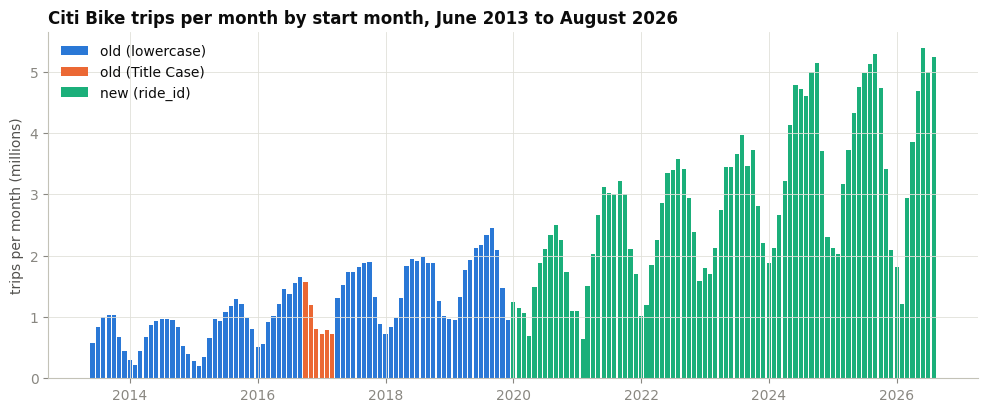

In [18]:
FORMAT_COLOURS = {"old": "#2a78d6", "old_title_case": "#eb6834", "new": "#1baf7a"}
FORMAT_LABELS = {"old": "old (lowercase)", "old_title_case": "old (Title Case)", "new": "new (ride_id)"}

fig, ax = plt.subplots(figsize=(12, 4.5))
for csv_format, colour in FORMAT_COLOURS.items():
    series = monthly_by_format[csv_format].dropna()
    series = series[series > 1000] / 1e6  # drops the handful of new-system trips that started before 2020
    ax.bar(series.index, series.values, width=24, color=colour, label=FORMAT_LABELS[csv_format])
ax.set_ylabel("trips per month (millions)")
ax.set_title("Citi Bike trips per month by start month, June 2013 to August 2026", loc="left")
ax.set_ylim(0, None)
ax.legend(loc="upper left", frameon=False)
plt.show()

- **No gap:** every month from June 2013 to August 2026 has trips, and the line has no jump at the two format changes (October 2016, January 2020), so the harmonisation did not shift the counts.
- **Growth:** from 8.1 million trips in 2014 to 45.8 million in 2025, more than five times as many. January to August 2026 (30.2 million) is level with the same months of 2025 (30.2 million).
- **Seasons:** every year has a winter low and a summer/autumn high; in 2025 the busiest month (September, 5.3 million) had 2.6 times as many trips as the quietest (February, 2.0 million).
- **Dips:** April 2020 (COVID-19 lockdown) and February 2026 stand out; the next cell quantifies them.

### 6.3 Each month compared with the same month a year earlier

Because of the strong seasons, a month can only be judged against the same month in another year. The heatmap shows the change in trips compared with the same month one year earlier: blue is growth, red is decline, grey is no change. A month with missing days or a broken file would show up as an isolated red cell.

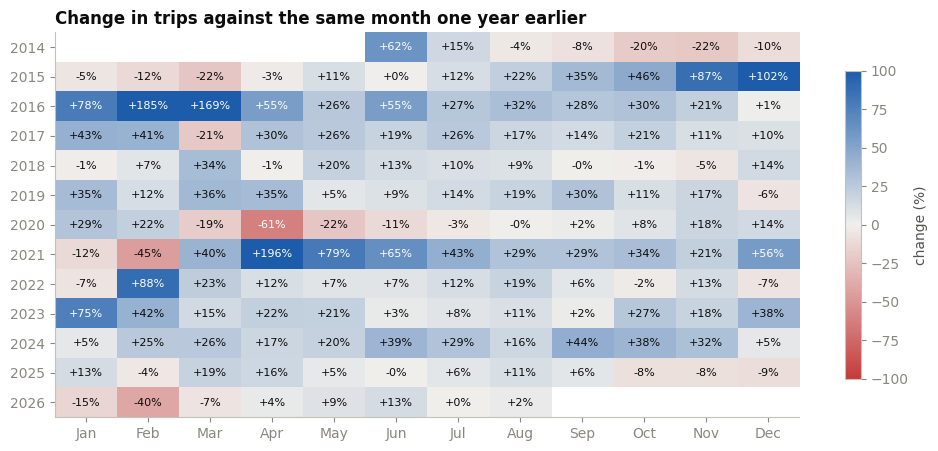

Largest declines:
2020-04-01   -61.2
2021-02-01   -44.6
2026-02-01   -40.0
2020-05-01   -22.5
2015-03-01   -22.2


In [19]:
yoy = (monthly / monthly.shift(12) - 1) * 100  # percent change against the same month a year earlier
yoy_table = yoy.dropna().to_frame("change").assign(year=lambda d: d.index.year, month=lambda d: d.index.month)
yoy_table = yoy_table.pivot(index="year", columns="month", values="change")

fig, ax = plt.subplots(figsize=(12, 5))
image = ax.imshow(yoy_table.values, cmap=DIVERGING, vmin=-100, vmax=100, aspect="auto")
ax.set_xticks(range(12), [name[:3] for name in MONTH_NAMES])
ax.set_yticks(range(len(yoy_table)), yoy_table.index)
for (row, col), value in np.ndenumerate(yoy_table.values):
    if not np.isnan(value):
        ax.text(col, row, f"{value:+.0f}%", ha="center", va="center", fontsize=8,
                color="white" if abs(value) > 55 else INK_PRIMARY)
ax.grid(False)
ax.set_title("Change in trips against the same month one year earlier", loc="left")
fig.colorbar(image, ax=ax, label="change (%)", shrink=0.8)
plt.show()

print("Largest declines:")
print(yoy.dropna().sort_values().head(5).round(1).to_string())

Almost all cells are blue: the system grew in nearly every month. Only three months fell by more than a quarter, and each has an outside explanation:

- **April 2020: -61%** (684,573 trips against 1,766,106 in April 2019). New York's COVID-19 lockdown; May 2020 is still -22%, and from June 2020 the numbers are back above 2019.
- **February 2021: -45%**. This month contains a day without trips and a day with only 241 trips (6.4).
- **February 2026: -40%** (1,219,706 trips against 2,031,394). The daily numbers show very few trips from 25 January 2026 onwards (3,053 that day, around 20,000 a day in the following week against 60,000 to 97,000 a day in the week before) and one day without trips (6.4).

The daily weather data planned for the next notebook should explain the two February dips.

There is no isolated red month without such an explanation, so we find no sign of missing data inside the months. The dark blue cells (e.g. +185% in February 2016, +196% in April 2021) are growth after a weak or disrupted month a year earlier, not double counting: step 1 showed that every trip is stored once.

### 6.4 Days without trips

The daily totals over the whole period. Days with **no trip at all** are marked; a day without any trip in a system with tens of thousands of trips per day means the system was closed or the data of that day is missing.

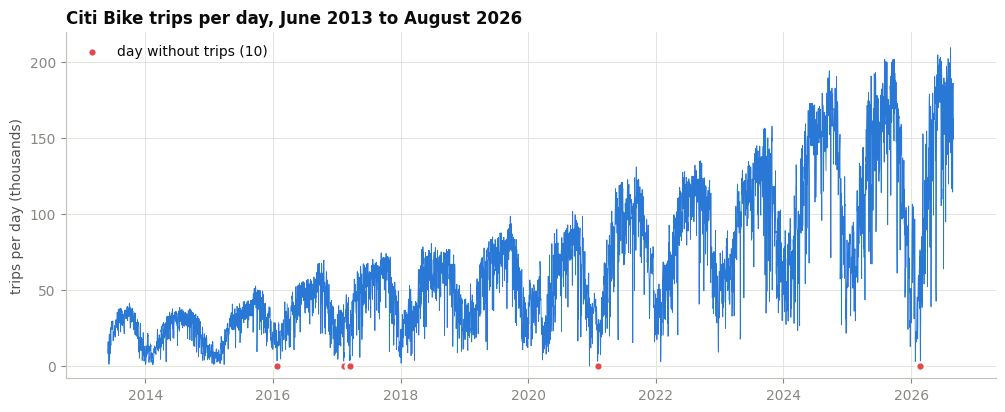

In [20]:
zero_days = daily[daily == 0]

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(daily.index, daily.values / 1e3, color=FORMAT_COLOURS["old"], linewidth=0.6)
ax.scatter(zero_days.index, np.zeros(len(zero_days)), color="#e34948", s=36, zorder=3,
           edgecolor="white", linewidth=1.5, label=f"day without trips ({len(zero_days)})")
ax.set_ylabel("trips per day (thousands)")
ax.set_title("Citi Bike trips per day, June 2013 to August 2026", loc="left")
ax.set_ylim(-8, None)
ax.legend(loc="upper left", frameon=False)
plt.show()

The daily line shows the same growth and seasons, with a lot of day-to-day variation (weekdays against weekends, rain). The days without trips are all in winter. To see whether they are isolated data gaps or part of a disruption, we list each one with the trips on the day before and after, and compare with the median of the surrounding four weeks.

In [21]:
typical = daily.rolling(29, center=True, min_periods=10).median()  # typical day in the surrounding 4 weeks
zero_table = pd.DataFrame({
    "weekday": zero_days.index.day_name(),
    "day_before": [daily.get(d - pd.Timedelta(days=1)) for d in zero_days.index],
    "day_after": [daily.get(d + pd.Timedelta(days=1)) for d in zero_days.index],
    "typical_day": typical[zero_days.index].round(),
}, index=zero_days.index.strftime("%Y-%m-%d"))
zero_table

,weekday,day_before,day_after,typical_day
2016-01-23,Saturday,20950,0,16933.0
2016-01-24,Sunday,0,0,16933.0
2016-01-25,Monday,0,0,17281.0
2016-01-26,Tuesday,0,6761,17281.0
2017-02-09,Thursday,40428,1997,29632.0
2017-03-14,Tuesday,27417,0,26927.0
2017-03-15,Wednesday,0,0,26927.0
2017-03-16,Thursday,0,7098,26927.0
2021-02-02,Tuesday,241,6392,25409.0
2026-02-23,Monday,19037,13135,54992.0


The 10 days without trips form 5 episodes: 23-26 January 2016, 9 February 2017, 14-16 March 2017, 2 February 2021 and 23 February 2026. Two more days are almost empty: 1 February 2021 (241 trips, the day before the zero day) and 17 December 2020 (180 trips). The day **after** every episode is far below a typical day: between 1,997 and 13,135 trips, against 17,000 to 55,000 on a typical day around those dates, and the following days recover gradually. The day **before** is mostly normal (for 23 January 2016 it is even busier than usual, 20,950 trips); only in 2021 and 2026 the decline starts a day earlier (241 and 19,037 trips). A sudden stop followed by a slow recovery is the pattern of a system that is closed for a storm and reopens when the streets are cleared. Missing data would look different: a gap between two normal days. Two of these dates are well-known New York blizzards (23 January 2016 and 14 March 2017); the zero counts suggest that Citi Bike suspended its service during them. The other dates are winter days as well; we will check all of them against daily weather data in the next notebook.

**Conclusion of step 2:** the data is complete over time. Every month and every day from June 2013 to August 2026 is present, except 10 winter days on which the system carried no trips. These are real events, not data errors, so they stay in the data. They matter later: a model of daily demand must not be trained to predict zero trips from the calendar alone; weather explains them.

## 7. Summary so far

- **Input:** the 400 CSVs directly inside the month folders (60.9 GB, June 2013 to August 2026, no month missing). The 19 unsplit copies in `Origineel/` are skipped; 4.2 proves they hold exactly the same trips.
- **Output:** one harmonised table of **323,817,107 trips** in 159 Parquet files (`Data/parquet/trips/`, about 10 GB instead of 61 GB), with one schema for the three CSV formats (3.1).
- **Fixes during the conversion:** fixed CSV dialect (quoted station names), four timestamp shapes, old station ids written as decimals, new station ids written with one decimal (3.2).
- **Duplicates:** 531 trips stored twice (512 at the April/May 2026 boundary, 19 in the old system) are stored once now; the removed copies are kept in `Data/parquet/removed_duplicates.parquet`.
- **Verified:** every CSV line is accounted for (4.1), no unreadable timestamps (4.3), no duplicate keys left (4.4).
- **Complete over time (6):** every month and every day from June 2013 to August 2026 has trips, except 10 winter days without any trip (storms, kept as real events). The old system files trips by start month, the new system by end month (except April 2026), so all counts use `started_at`.

Not yet done (next steps of this notebook): data-quality checks per column (durations, coordinates, birth years, the 7,072 trips that started more than a day before their file month, round trips), a first overview with graphs, and the table of cleaning decisions for the data-preparation notebook.